## MCMC sampling

In this example, we show how to sample our trained surrogate model using both the `emcee` and `dynesty` samplers. 

In [1]:
%matplotlib inline
from functools import partial
import alabi

from matplotlib import rcParams
# rcParams['font.family'] = 'serif'
# rcParams['text.usetex'] = True

First, we need to define the same function that was used when creating the cached model, then we can reload our results from the previous tutorial:

In [2]:
# Redefine in this notebook so that pickle file can be loaded
from scipy.optimize import rosen

def rosenbrock_fn(x):
    return -rosen(x)/100.0

bounds = [(-5,5), (-5,5)]
param_names = ['x1', 'x2']

In [3]:
import os
if not os.path.exists("results/rosenbrock_2d/surrogate_model.pkl"):
    sm_tmp = alabi.SurrogateModel(lnlike_fn=rosenbrock_fn, bounds=bounds,
                                  param_names=param_names,
                                  savedir="results/rosenbrock_2d", cache=True)
    sm_tmp.init_samples(ntrain=100, ntest=1000, sampler="sobol")
    sm_tmp.init_gp(kernel="ExpSquaredKernel", fit_amp=True, fit_mean=True,
                   white_noise=-12, gp_opt_method="l-bfgs-b")
    sm_tmp.active_train(niter=100, algorithm="bape", gp_opt_freq=20)
    del sm_tmp
sm = alabi.load_model_cache("results/rosenbrock_2d")

### Sampling with `emcee`

First, let's run emcee with default settings (uniform prior):

In [4]:
import alabi.utility as ut

# In this example we will set up a uniform prior within the parameter bounds
prior_fn = partial(ut.lnprior_uniform, bounds=sm.bounds)  # Use bounds from loaded model

sm.run_emcee(
    like_fn=sm.surrogate_log_likelihood,    # use like_fn=sm.true_log_likelihood to sample the true function
    prior_fn=prior_fn,                      # if None, defaults to uniform prior within bounds
    nwalkers=4,
    nsteps=int(2e4),
    burn=int(1e3),
    multi_proc=True,
    min_ess=1000
)

Running emcee with 4 walkers for 20000 steps on 1 cores...

Run 1: Need 1000 more samples...


100%|██████████| 20000/20000 [00:46<00:00, 427.49it/s]


burn-in estimate: 336
thin estimate: 55

Run 1 complete: 1380 samples
Total accumulated samples: 1380
Total samples: 1380
Mean acceptance fraction: 0.524
Mean autocorrelation time: 139.952 steps
Caching model to results/rosenbrock_2d/surrogate_model...
Saving final emcee samples to results/rosenbrock_2d/emcee_samples_final_likelihood_iter_100.npz ...


Plotting emcee posterior...
Saving to  results/rosenbrock_2d/emcee__posterior_likelihood.png


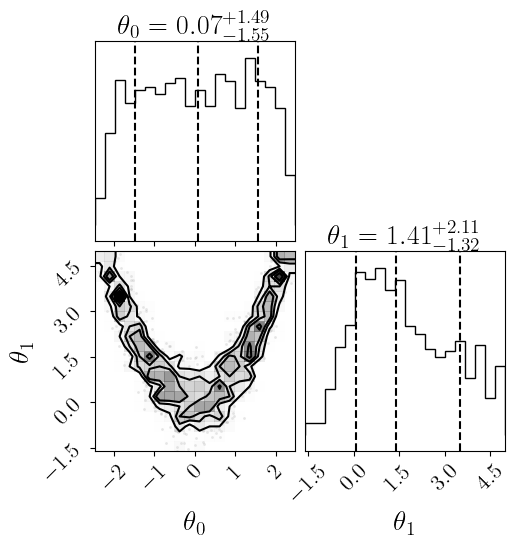

In [5]:
sm.plot(plots=["emcee_corner"]);

### Sampling with `dynesty`

Now let's use the `dynesty` nested sampler for comparison with default settings (uniform prior):

In [6]:
# Set up uniform prior - dynesty requires separate prior transform function
prior_transform = partial(ut.prior_transform_uniform, bounds=sm.bounds)  # Use bounds from loaded model

dynesty_sampler_kwargs = {"bound": "single",
                          "nlive": 100,
                          "sample": "auto"}

dynesty_run_kwargs = {"wt_kwargs": {'pfrac': 1.0},      # set weights to 100% posterior, 0% evidence
                      "stop_kwargs": {'pfrac': 1.0},
                      "maxiter": int(2e4),
                      "dlogz_init": 0.5}
    
sm.run_dynesty(like_fn=sm.surrogate_log_likelihood,    # use like_fn=sm.true_log_likelihood to sample the true function
               prior_transform=prior_transform,        # if None, defaults to uniform prior within bounds
               multi_proc=False,                       # optional parallelization (oftentimes not worth it for dynesty)
               sampler_kwargs=dynesty_sampler_kwargs, 
               run_kwargs=dynesty_run_kwargs,
               min_ess=1000)

Initializing dynesty with self.surrogate_log_likelihood surrogate model as likelihood.
Initialized dynesty DynamicNestedSampler.
Running dynesty with 100 live points on 1 cores...

Run 1: Need 1000 more samples...


10569it [01:22, 127.78it/s, batch: 42 | bound: 11 | nc: 1 | ncall: 145458 | eff(%):  7.235 | loglstar: -2.350 <  0.009 < -0.180 | logz: -2.616 +/-  0.042 | stop:  0.987]     


Run 1 complete: 10569 samples, logZ = -2.616
Total accumulated samples: 10569
Caching model to results/rosenbrock_2d/surrogate_model...
Saved dynesty samples to results/rosenbrock_2d/dynesty_samples_final_surrogate_iter_100.npz


Plotting dynesty posterior...
Saving to  results/rosenbrock_2d/dynesty__posterior_surrogate.png


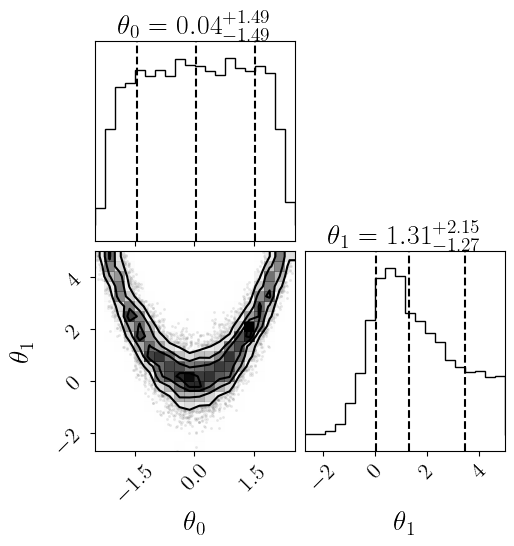

In [7]:
sm.plot(plots=["dynesty_corner"]);

Plotting dynesty traceplot...
Saving to  results/rosenbrock_2d/dynesty_traceplot_surrogate.png


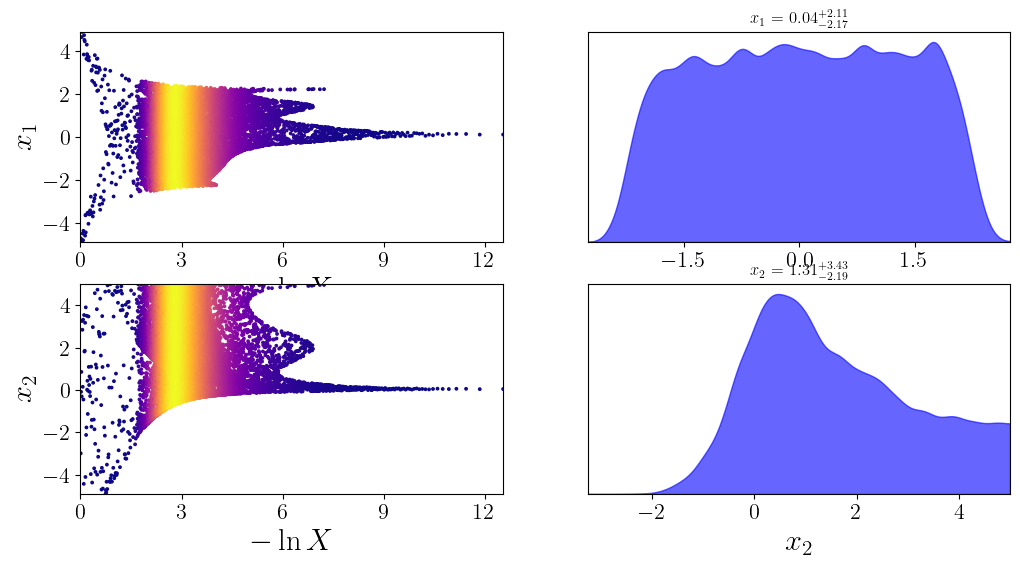

In [8]:
sm.plot(plots=["dynesty_traceplot"]);

Plotting dynesty runplot...
Saving to  results/rosenbrock_2d/dynesty_runplot_surrogate.png


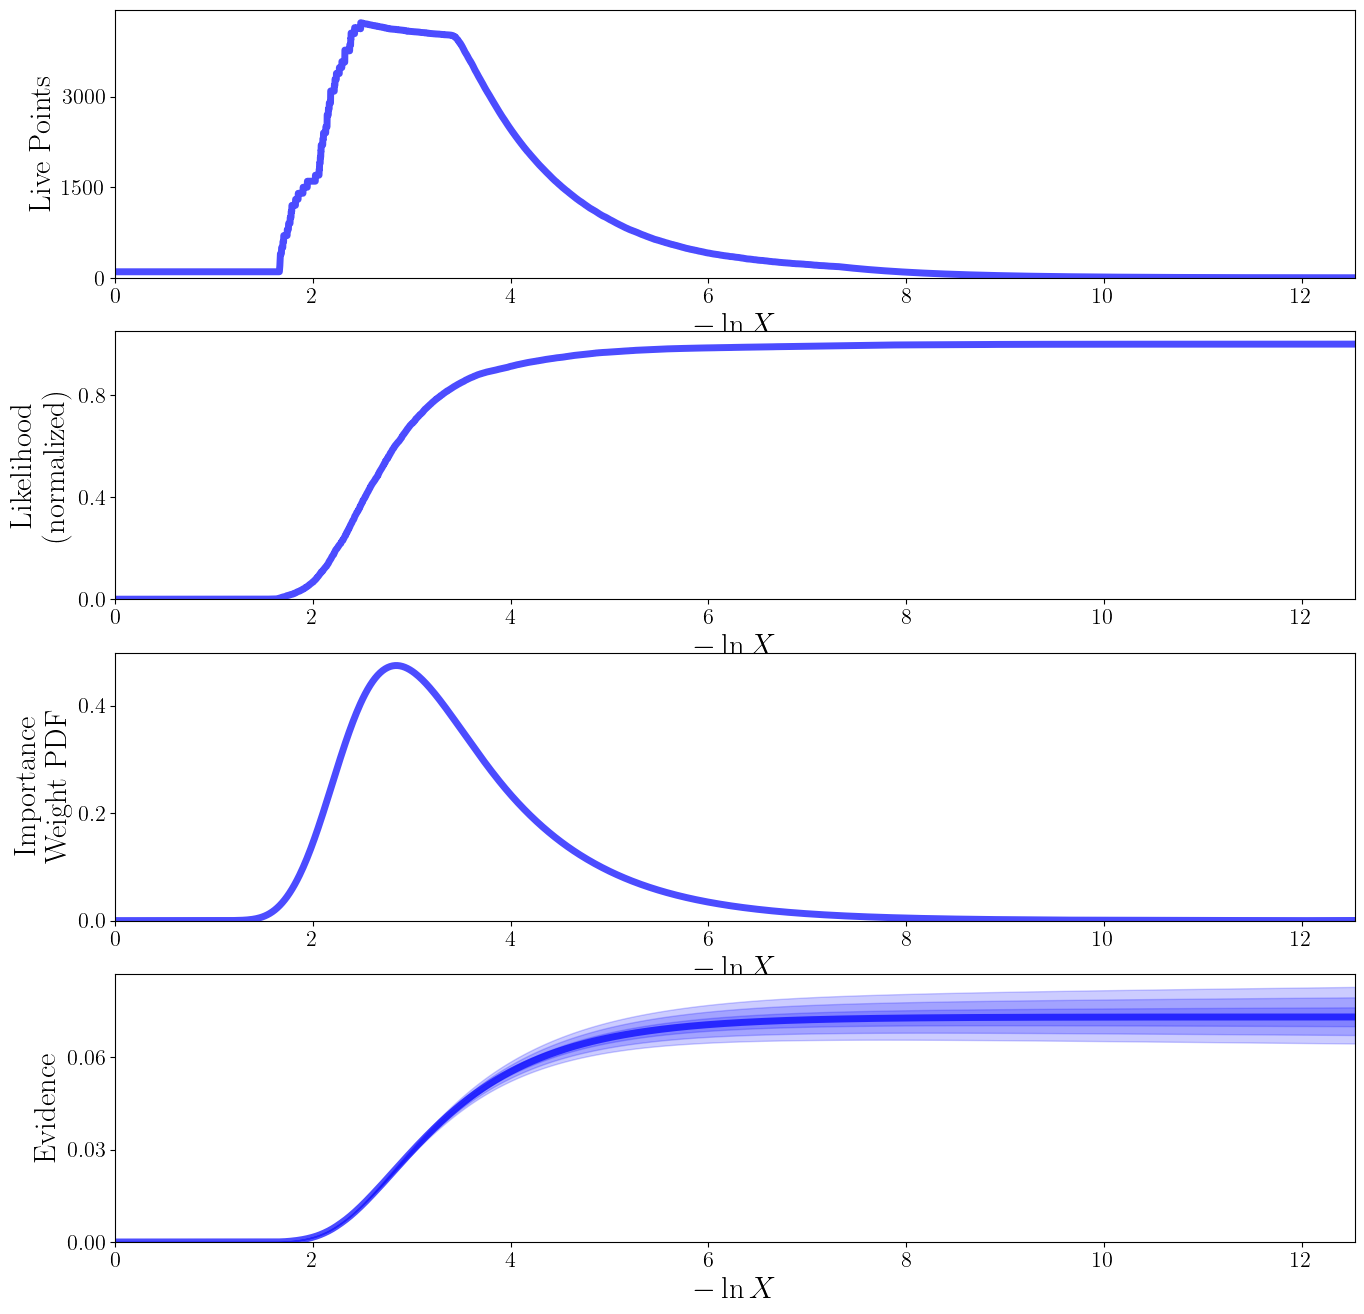

In [9]:
sm.plot(plots=["dynesty_runplot"]);